In [38]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

In [39]:
data = pd.read_csv("projet1.csv")

In [40]:
data.shape

(768, 9)

In [41]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [43]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [44]:
cols_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_info = pd.DataFrame({
    'Variable': cols_zeros,
    'Nb_zeros': [(data[col] == 0).sum() for col in cols_zeros],
    'Pourcentage': [(data[col] == 0).mean() * 100 for col in cols_zeros]
}).round(2)

print(zero_info)

        Variable  Nb_zeros  Pourcentage
0        Glucose         5         0.65
1  BloodPressure        35         4.56
2  SkinThickness       227        29.56
3        Insulin       374        48.70
4            BMI        11         1.43


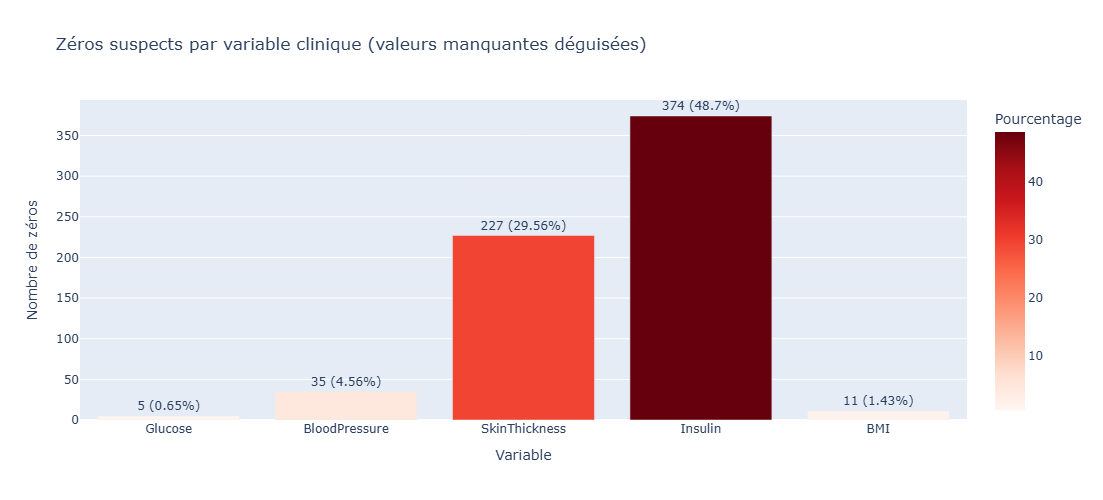

In [45]:
fig = px.bar(
    zero_info,
    x='Variable', y='Nb_zeros',
    text=zero_info.apply(lambda r: f"{int(r['Nb_zeros'])} ({r['Pourcentage']}%)", axis=1),
    color='Pourcentage',
    color_continuous_scale='Reds',
    title="Zéros suspects par variable clinique (valeurs manquantes déguisées)",
    labels={'Nb_zeros': 'Nombre de zéros'}
)
fig.update_traces(textposition='outside')
fig.update_layout(height=500)
fig.show()

In [46]:
data_clean = data.copy()
data_clean[cols_zeros] = data_clean[cols_zeros].replace(0, np.nan)

for col in cols_zeros:
    for outcome_val in [0, 1]:
        mask = (data_clean['Outcome'] == outcome_val) & (data_clean[col].isna())
        median_val = data_clean[data_clean['Outcome'] == outcome_val][col].median()
        data_clean.loc[mask, col] = median_val

print("Valeur manquantes après imputation:", data_clean.isna().sum().sum())

Valeur manquantes après imputation: 0


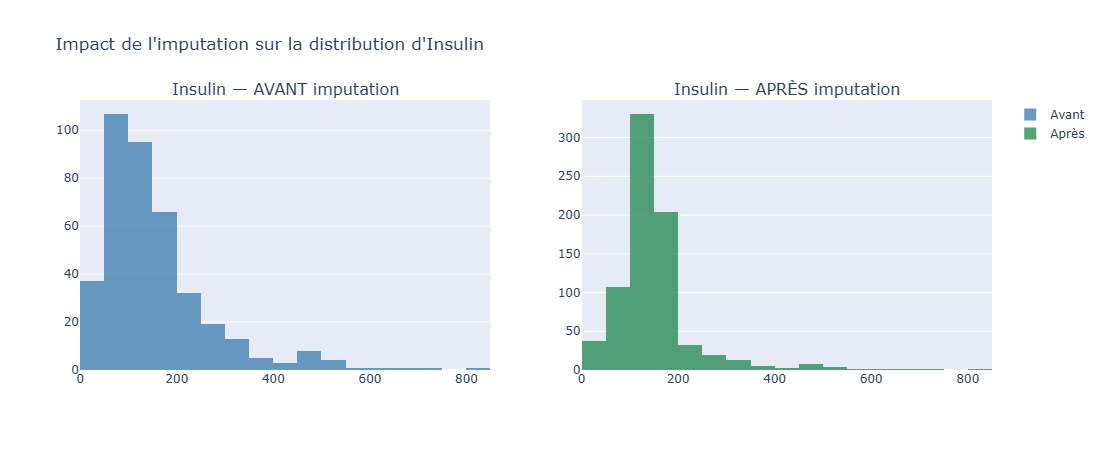

In [47]:

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=["Insulin — AVANT imputation", "Insulin — APRÈS imputation"])

fig.add_trace(
    go.Histogram(x=data['Insulin'].replace(0, np.nan).dropna(),
                 nbinsx=30, name='Avant', marker_color='steelblue', opacity=0.8),
    row=1, col=1
)
fig.add_trace(
    go.Histogram(x=data_clean['Insulin'],
                 nbinsx=30, name='Après', marker_color='seagreen', opacity=0.8),
    row=1, col=2
)

fig.update_layout(title="Impact de l'imputation sur la distribution d'Insulin",
                  height=450, showlegend=True)
fig.show()

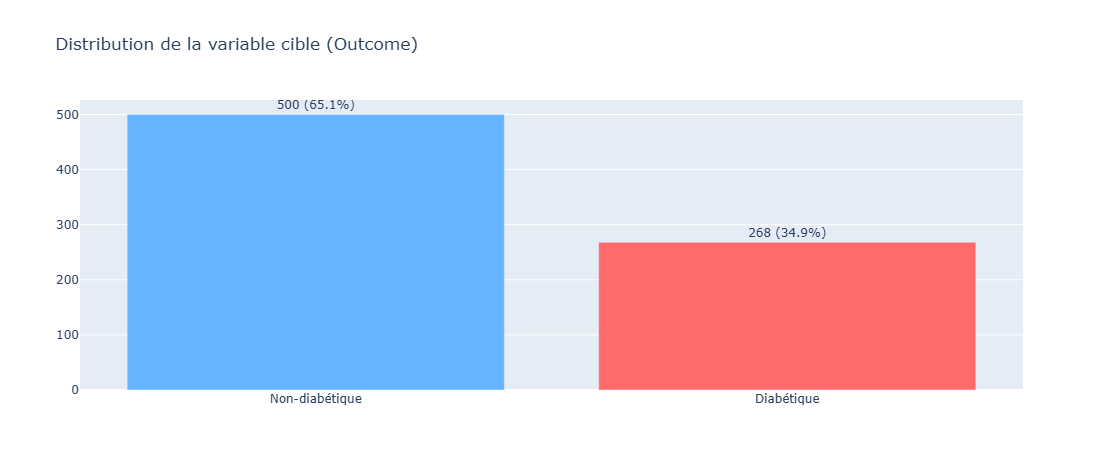

In [48]:
outcome_counts = data_clean['Outcome'].value_counts().reset_index()
outcome_counts.columns = ['Outcome', 'Count']
outcome_counts['Label'] = outcome_counts['Outcome'].map({0: 'Non-diabétique', 1: 'Diabétique'})
outcome_counts['Pct'] = (outcome_counts['Count'] / len(data_clean) * 100).round(1)

fig = go.Figure()

fig.add_trace(
    go.Bar(x=outcome_counts['Label'], y=outcome_counts['Count'],
           text=outcome_counts.apply(lambda r: f"{r['Count']} ({r['Pct']}%)", axis=1),
           textposition='outside',
           marker_color=['#66b3ff', '#ff6b6b']),
)

fig.update_layout(title="Distribution de la variable cible (Outcome)",
                  height=470, showlegend=False)
fig.show()

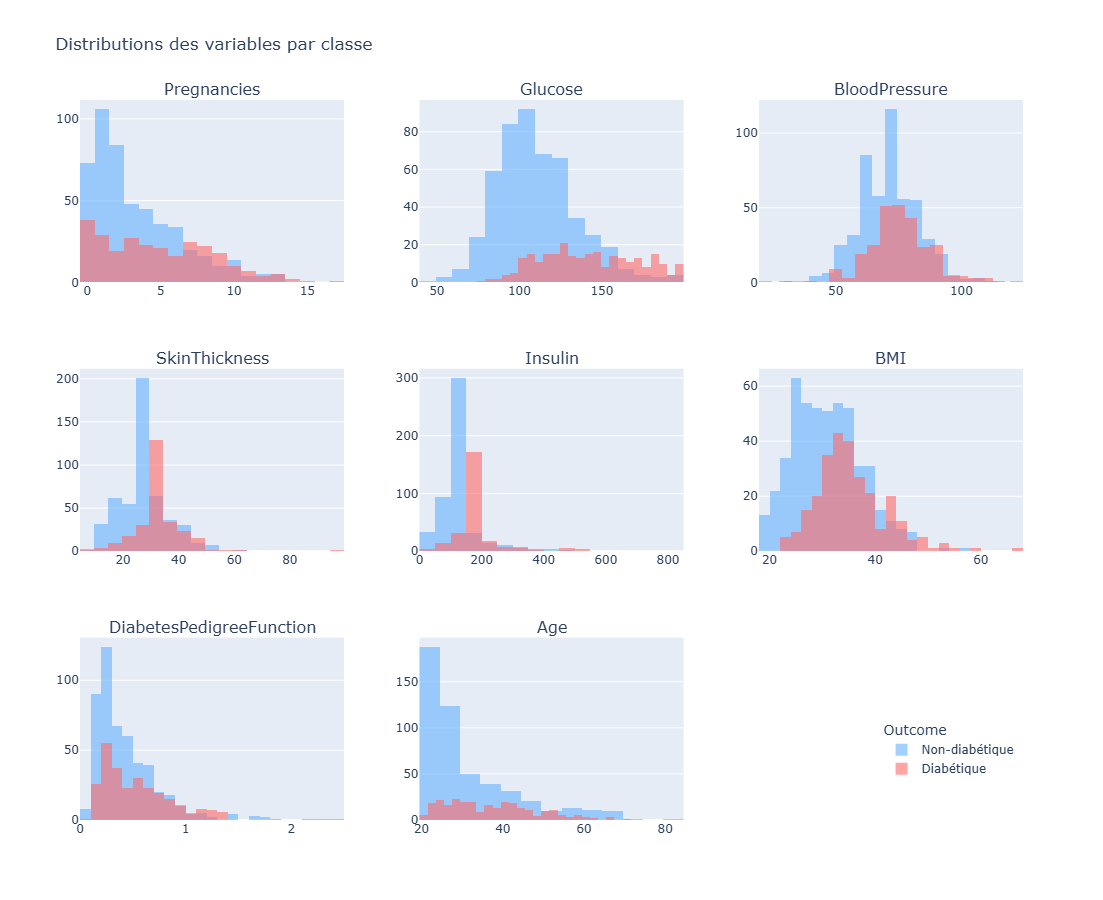

In [49]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig = make_subplots(rows=3, cols=3,
                    subplot_titles=features,
                    vertical_spacing=0.12, horizontal_spacing=0.08)

colors = {0: '#66b3ff', 1: '#ff6b6b'}
labels = {0: 'Non-diabétique', 1: 'Diabétique'}

for i, col in enumerate(features):
    row, col_idx = divmod(i, 3)
    for outcome_val in [0, 1]:
        subset = data_clean[data_clean['Outcome'] == outcome_val][col]
        fig.add_trace(
            go.Histogram(x=subset, name=labels[outcome_val],
                         marker_color=colors[outcome_val],
                         opacity=0.6, nbinsx=25,
                         showlegend=(i == 0)),
            row=row + 1, col=col_idx + 1
        )

fig.update_layout(
    title="Distributions des variables par classe",
    height=900, barmode='overlay',
    legend=dict(title='Outcome', x=0.85, y=0.05)
)
fig.show()

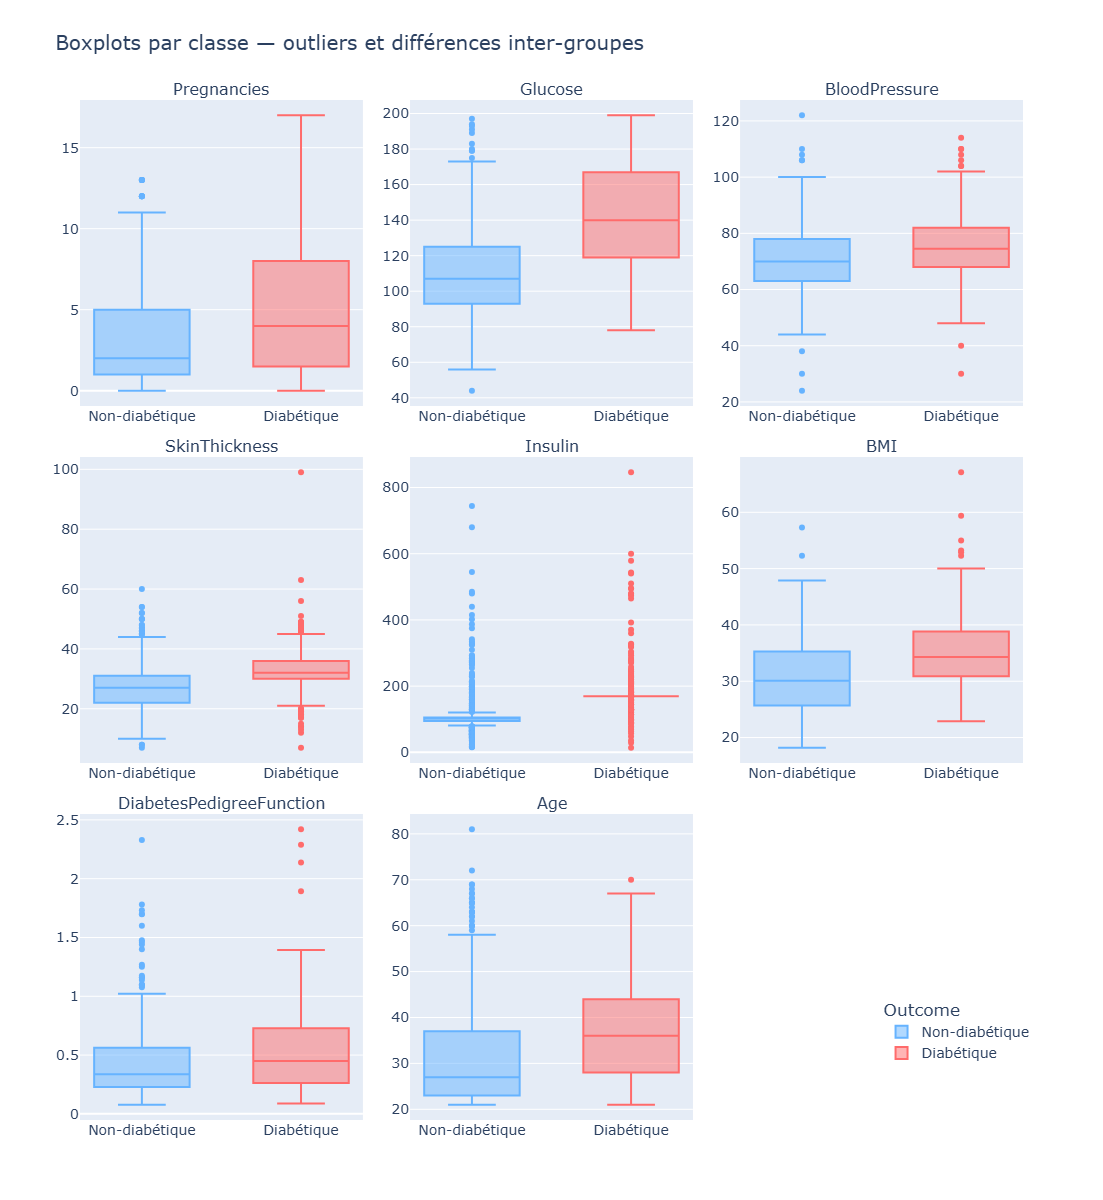

In [50]:
fig = make_subplots(rows=3, cols=3,
                    subplot_titles=features,
                    vertical_spacing=0.05, horizontal_spacing=0.05)

for i, col in enumerate(features):
    row, col_idx = divmod(i, 3)
    for outcome_val in [0, 1]:
        subset = data_clean[data_clean['Outcome'] == outcome_val][col]
        fig.add_trace(
            go.Box(y=subset, name=labels[outcome_val],
                   marker_color=colors[outcome_val],
                   width=0.6,
                   showlegend=(i == 0)),
            row=row + 1, col=col_idx + 1
        )

fig.update_layout(
    font=dict(size=14),
    title="Boxplots par classe — outliers et différences inter-groupes",
    height=1200,width=900, boxmode='group',
    legend=dict(title='Outcome', x=0.85, y=0.05)
)
fig.show()

In [51]:
results = []
for col in features:
    g0 = data_clean[data_clean['Outcome'] == 0][col]
    g1 = data_clean[data_clean['Outcome'] == 1][col]
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    results.append({
        'Variable': col,
        'p_value': p,
        'Significatif': ' OUI' if p < 0.05 else ' NON'
    })

results_df = pd.DataFrame(results).sort_values('p_value')
print(results_df.to_string(index=False))

                Variable      p_value Significatif
                 Insulin 8.285050e-55          OUI
                 Glucose 3.443989e-41          OUI
           SkinThickness 2.921654e-23          OUI
                     BMI 4.924719e-18          OUI
                     Age 1.142200e-17          OUI
             Pregnancies 3.745146e-08          OUI
           BloodPressure 2.258749e-07          OUI
DiabetesPedigreeFunction 1.196583e-06          OUI


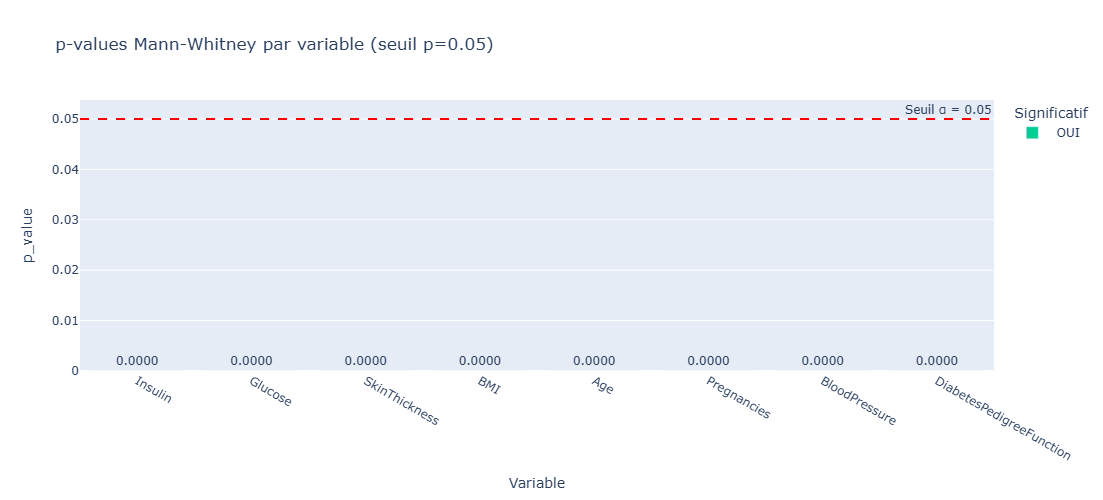

In [52]:
fig = px.bar( 
results_df, 
x='Variable', y='p_value', 
color='Significatif', 
color_discrete_map={'✓ OUI': 'seagreen', '✗ NON': 'salmon'}, 
title="p-values Mann-Whitney par variable (seuil p=0.05)", 
text='p_value' 
) 
fig.add_hline(y=0.05, line_dash='dash', line_color='red', 
annotation_text="Seuil α = 0.05") 
fig.update_traces(texttemplate='%{text:.4f}', textposition='outside') 
fig.update_layout(height=500) 
fig.show()

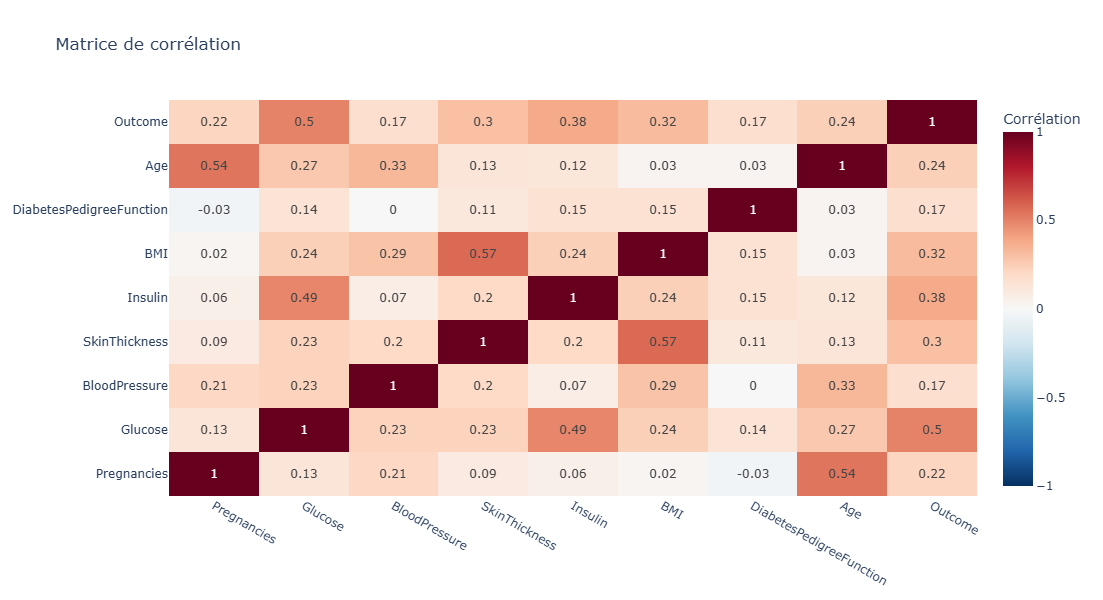

In [53]:
corr = data_clean.corr(numeric_only=True).round(2)

fig = go.Figure(go.Heatmap(
    z=corr.values,
    x=corr.columns.tolist(),
    y=corr.columns.tolist(),
    colorscale='RdBu_r',
    zmid=0,
    text=corr.values,
    texttemplate='%{text}',
    colorbar=dict(title='Corrélation')
))

fig.update_layout(
    title="Matrice de corrélation",
    height=600, width=700
)
fig.show()

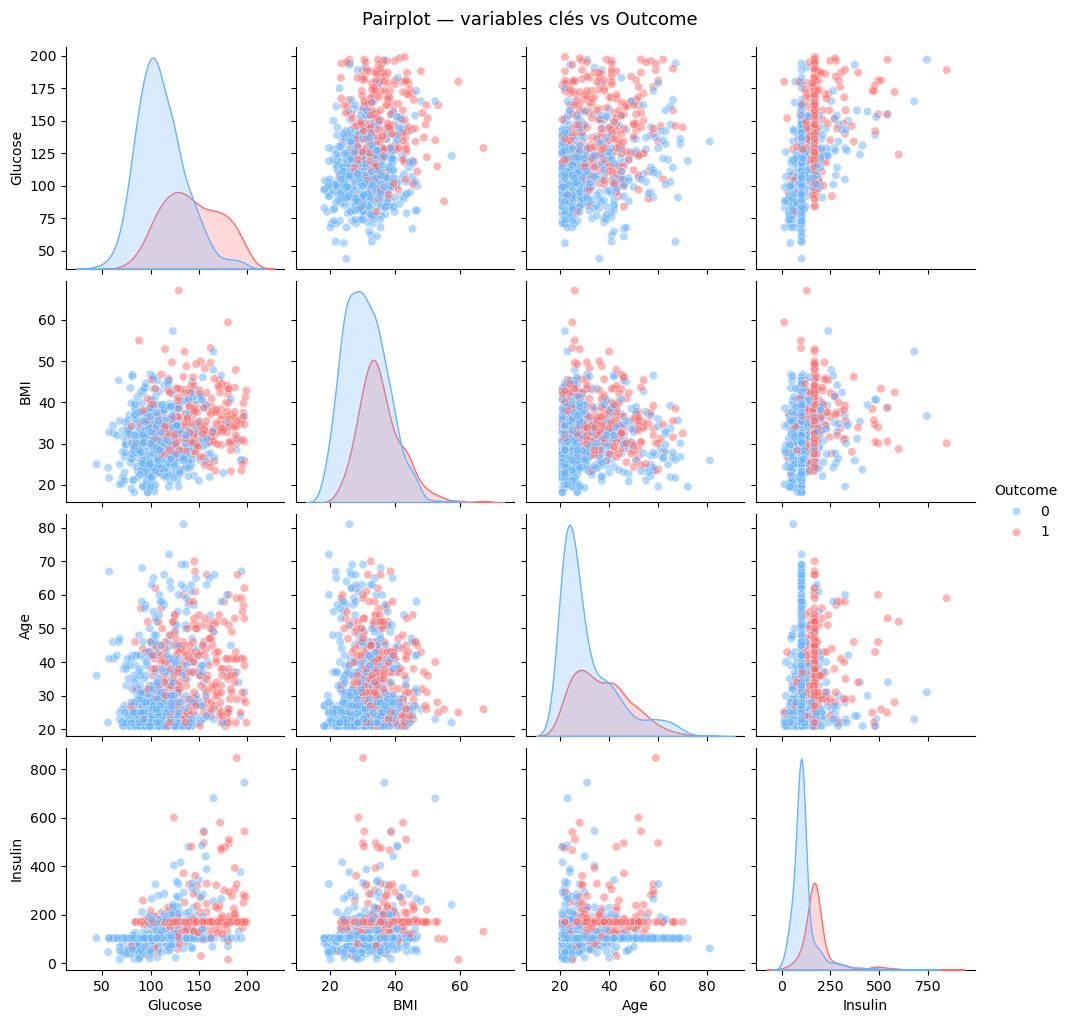

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
key_vars = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']

sns.pairplot(data_clean[key_vars], hue='Outcome',
             palette={0: '#66b3ff', 1: '#ff6b6b'},
             diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Pairplot — variables clés vs Outcome", y=1.02, fontsize=13)
plt.show()

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = data_clean.drop('Outcome', axis=1)
y = data_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)   
X_test_scaled  = sc.transform(X_test)       

print(f"Train : {X_train_scaled.shape} | Test : {X_test_scaled.shape}")
print(f"Ratio diabétiques — Train : {y_train.mean()*100:.1f}% | Test : {y_test.mean()*100:.1f}%")

Train : (614, 8) | Test : (154, 8)
Ratio diabétiques — Train : 34.9% | Test : 35.1%


In [56]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print("Avant SMOTE :")
print(f"  Non-diabétiques : {(y_train == 0).sum()} | Diabétiques : {(y_train == 1).sum()}")
print("\nAprès SMOTE :")
print(f"  Non-diabétiques : {(y_train_sm == 0).sum()} | Diabétiques : {(y_train_sm == 1).sum()}")

Avant SMOTE :
  Non-diabétiques : 400 | Diabétiques : 214

Après SMOTE :
  Non-diabétiques : 400 | Diabétiques : 400


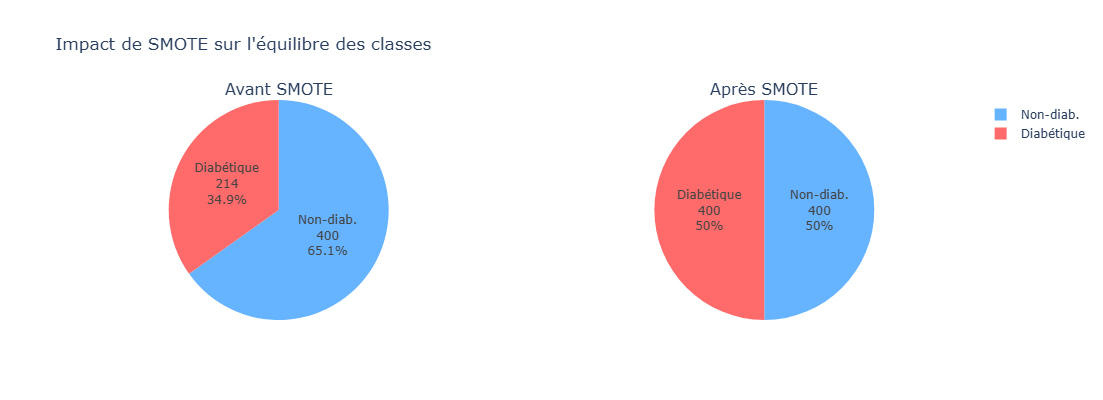

In [57]:

fig = make_subplots(rows=1, cols=2,
                    specs=[[{'type':'pie'}, {'type':'pie'}]],
                    subplot_titles=["Avant SMOTE", "Après SMOTE"])

for col_idx, (labels_data, values_data) in enumerate([
    (['Non-diab.', 'Diabétique'], [(y_train==0).sum(), (y_train==1).sum()]),
    (['Non-diab.', 'Diabétique'], [(y_train_sm==0).sum(), (y_train_sm==1).sum()])
]):
    fig.add_trace(
        go.Pie(labels=labels_data, values=values_data,
               marker_colors=['#66b3ff','#ff6b6b'],
               textinfo='label+percent+value'),
        row=1, col=col_idx+1
    )

fig.update_layout(title="Impact de SMOTE sur l'équilibre des classes", height=400)
fig.show()

In [58]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

k_values = range(1, 31)
f1_scores_sm = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sm, y_train_sm)
    y_pred = knn.predict(X_test_scaled)
    f1_scores_sm.append(f1_score(y_test, y_pred))

meilleur_k = k_values[f1_scores_sm.index(max(f1_scores_sm))]
print(f"Meilleur k (F1-Score) avec SMOTE : {meilleur_k}")

Meilleur k (F1-Score) avec SMOTE : 14


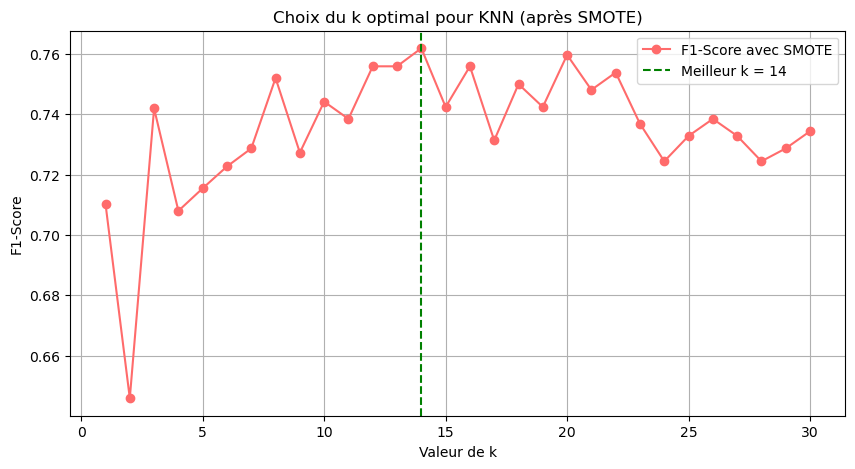

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(k_values, f1_scores_sm, marker='o', color='#ff6b6b', label='F1-Score avec SMOTE')
plt.axvline(x=meilleur_k, color='green', linestyle='--', label=f'Meilleur k = {meilleur_k}')
plt.title("Choix du k optimal pour KNN (après SMOTE)")
plt.xlabel("Valeur de k")
plt.ylabel("F1-Score")
plt.legend()
plt.grid(True)
plt.show()

In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score, recall_score)

models = {
    'KNN (k=14)':             KNeighborsClassifier(n_neighbors=14),
    'Logistic Regression':    LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42)
}

def evaluer_modele(nom, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    
    rapport = classification_report(y_te, y_pred, output_dict=True)
    return {
        'Modèle':     nom,
        'Accuracy':   round(rapport['accuracy'] * 100, 2),
        'Precision':  round(rapport['1']['precision'] * 100, 2),
        'Recall':     round(rapport['1']['recall'] * 100, 2),   
        'F1-Score':   round(rapport['1']['f1-score'] * 100, 2),
        'AUC-ROC':    round(roc_auc_score(y_te, y_proba) * 100, 2) if y_proba is not None else '-',
        'model_obj':  model,
        'y_pred':     y_pred,
        'y_proba':    y_proba
    }


resultats_sans = []
resultats_avec = []

for nom, model in models.items():
    import copy
    resultats_sans.append(evaluer_modele(
        nom, copy.deepcopy(model),
        X_train_scaled, y_train, X_test_scaled, y_test
    ))
    resultats_avec.append(evaluer_modele(
        nom + ' + SMOTE', copy.deepcopy(model),
        X_train_sm, y_train_sm, X_test_scaled, y_test
    ))

df_sans = pd.DataFrame(resultats_sans).drop(columns=['model_obj','y_pred','y_proba'])
df_avec = pd.DataFrame(resultats_avec).drop(columns=['model_obj','y_pred','y_proba'])

print("=== SANS SMOTE ===")
print(df_sans.to_string(index=False))
print("\n=== AVEC SMOTE ===")
print(df_avec.to_string(index=False))

=== SANS SMOTE ===
             Modèle  Accuracy  Precision  Recall  F1-Score  AUC-ROC
         KNN (k=14)     77.92      70.83   62.96     66.67    85.53
Logistic Regression     70.78      58.82   55.56     57.14    82.63
      Random Forest     86.36      81.13   79.63     80.37    94.47

=== AVEC SMOTE ===
                     Modèle  Accuracy  Precision  Recall  F1-Score  AUC-ROC
         KNN (k=14) + SMOTE     80.52      66.67   88.89     76.19    85.78
Logistic Regression + SMOTE     75.97      61.97   81.48     70.40    82.61
      Random Forest + SMOTE     87.01      80.36   83.33     81.82    94.45


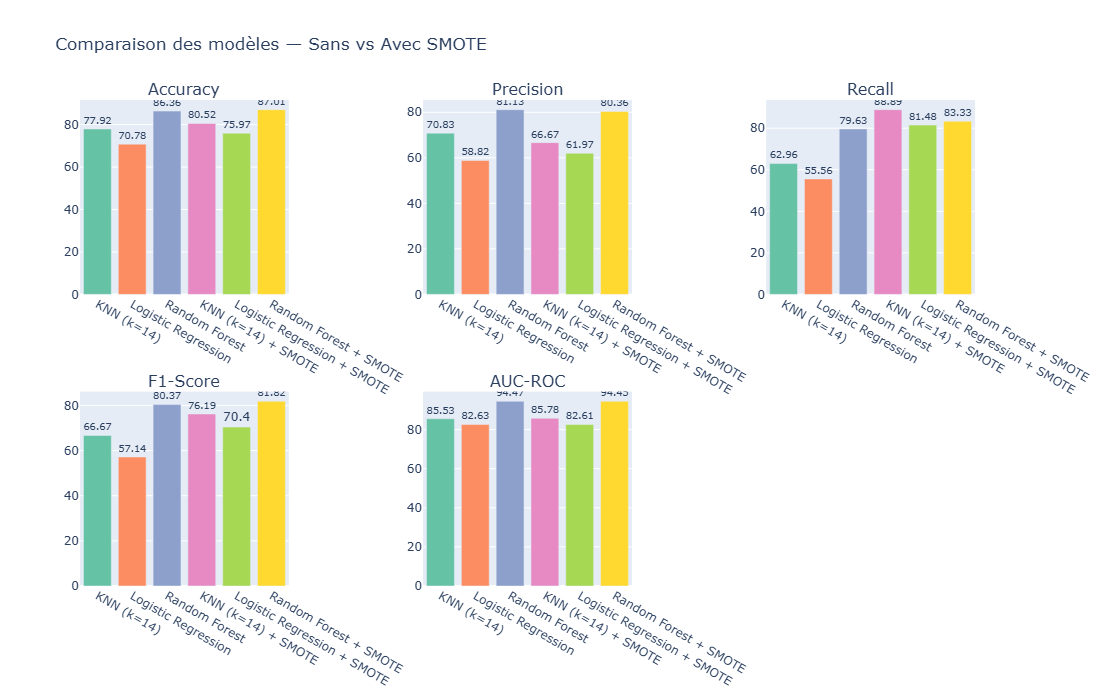

In [71]:
df_all = pd.concat([df_sans, df_avec], ignore_index=True)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=metrics,
    horizontal_spacing=0.15,  
    vertical_spacing=0.20     
)

colors = px.colors.qualitative.Set2

for idx, metric in enumerate(metrics):
    row, col = divmod(idx, 3)
    fig.add_trace(
        go.Bar(
            x=df_all['Modèle'], y=df_all[metric],
            text=df_all[metric], textposition='outside',
            marker_color=colors[:len(df_all)],
            showlegend=False
        ),
        row=row+1, col=col+1
    )

fig.update_layout(
    title="Comparaison des modèles — Sans vs Avec SMOTE",
    height=700
)
fig.show()     

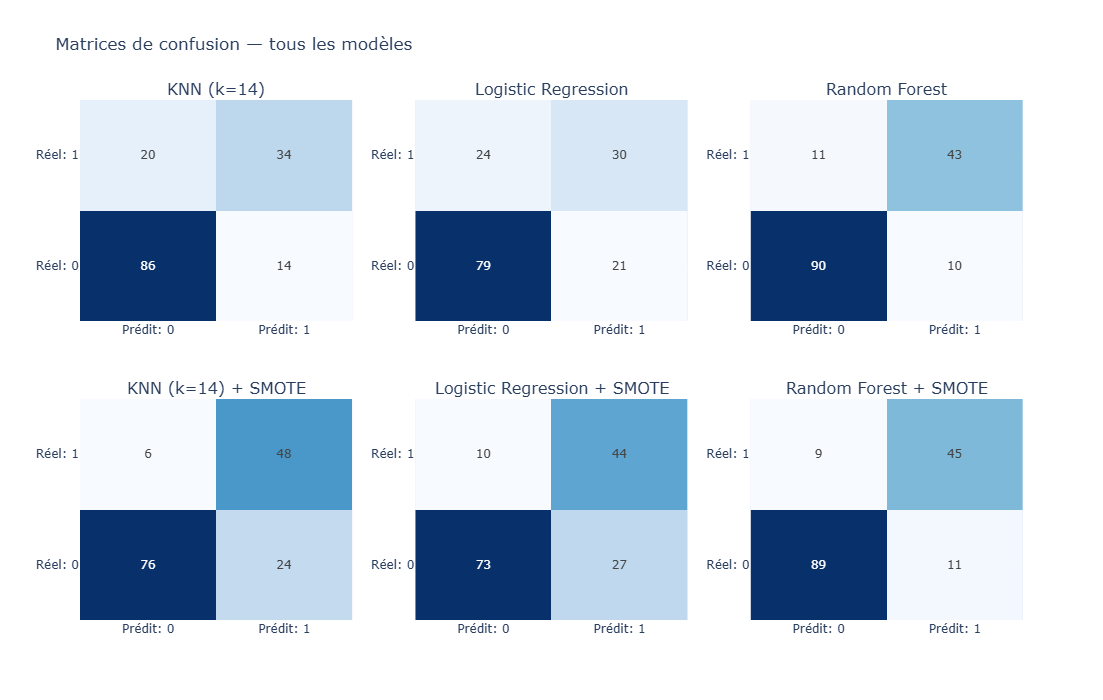

In [72]:
tous_resultats = resultats_sans + resultats_avec
fig = make_subplots(rows=2, cols=3,
                    subplot_titles=[r['Modèle'] for r in tous_resultats],
                    vertical_spacing=0.15)

for idx, res in enumerate(tous_resultats):
    row, col = divmod(idx, 3)
    cm = confusion_matrix(y_test, res['y_pred'])
    
    fig.add_trace(
        go.Heatmap(
            z=cm, x=['Prédit: 0', 'Prédit: 1'],
            y=['Réel: 0', 'Réel: 1'],
            colorscale='Blues',
            text=cm, texttemplate='%{text}',
            showscale=False
        ),
        row=row+1, col=col+1
    )

fig.update_layout(title="Matrices de confusion — tous les modèles", height=700)
fig.show()

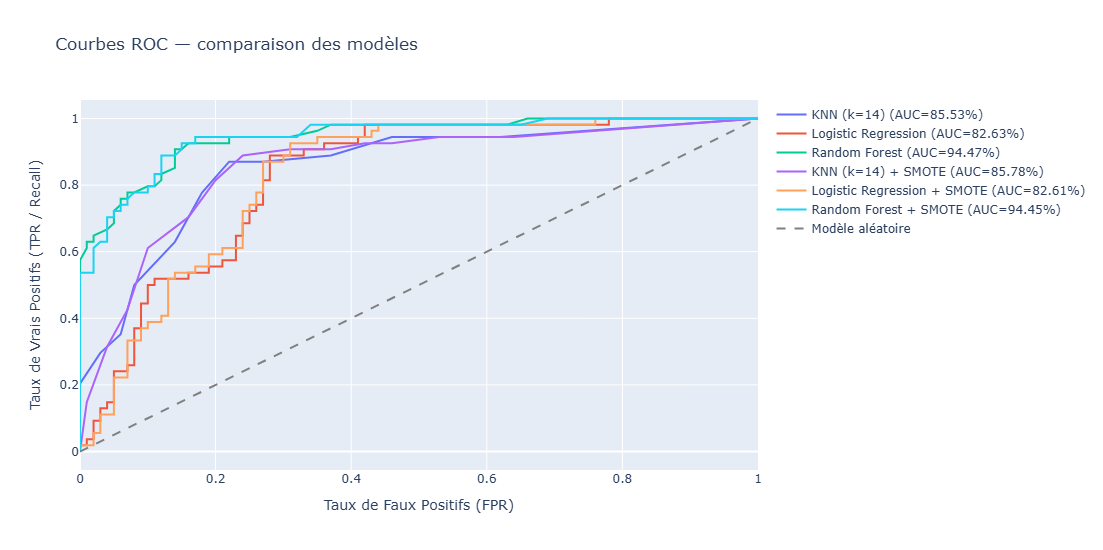

In [73]:
fig = go.Figure()

for res in tous_resultats:
    if res['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        fig.add_trace(go.Scatter(
            x=fpr, y=tpr, mode='lines',
            name=f"{res['Modèle']} (AUC={res['AUC-ROC']}%)"
        ))

fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1], mode='lines',
    line=dict(dash='dash', color='gray'),
    name='Modèle aléatoire'
))

fig.update_layout(
    title="Courbes ROC — comparaison des modèles",
    xaxis_title="Taux de Faux Positifs (FPR)",
    yaxis_title="Taux de Vrais Positifs (TPR / Recall)",
    height=550
)
fig.show()

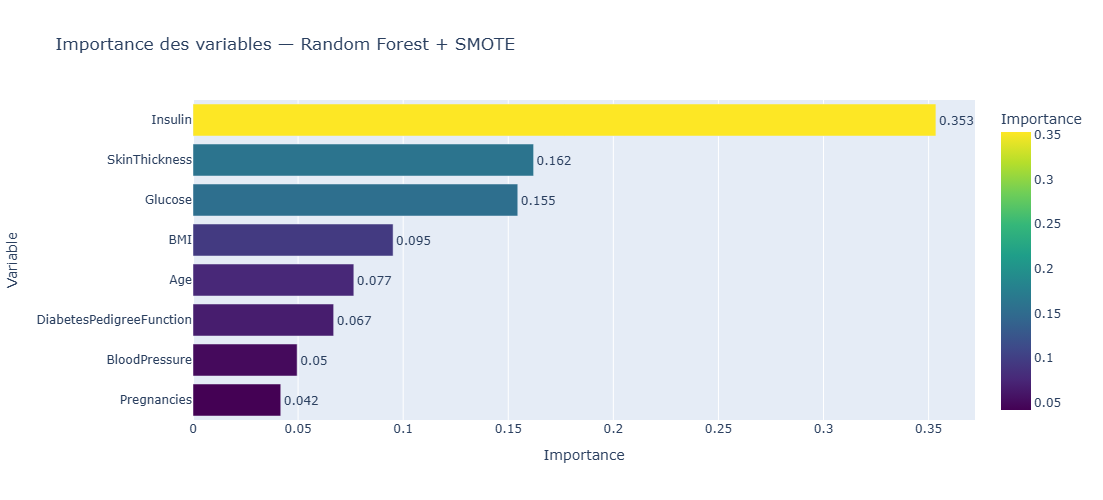

In [74]:

rf_smote = [r for r in resultats_avec if 'Random Forest' in r['Modèle']][0]['model_obj']

importance_df = pd.DataFrame({
    'Variable': X.columns,
    'Importance': rf_smote.feature_importances_
}).sort_values('Importance', ascending=True)

fig = px.bar(
    importance_df,
    x='Importance', y='Variable',
    orientation='h',
    color='Importance',
    color_continuous_scale='Viridis',
    title="Importance des variables — Random Forest + SMOTE",
    text=importance_df['Importance'].round(3)
)
fig.update_traces(textposition='outside')
fig.update_layout(height=500)
fig.show()

In [75]:
df_final = pd.concat([df_sans, df_avec], ignore_index=True).sort_values('Recall', ascending=False)

print("=== CLASSEMENT FINAL PAR RECALL (priorité médicale) ===\n")
print(df_final[['Modèle', 'Recall', 'F1-Score', 'AUC-ROC', 'Accuracy']].to_string(index=False))

meilleur = df_final.iloc[0]
print(f"\n Meilleur modèle : {meilleur['Modèle']}")
print(f"   Recall    : {meilleur['Recall']}%")
print(f"   F1-Score  : {meilleur['F1-Score']}%")
print(f"   AUC-ROC   : {meilleur['AUC-ROC']}%")

=== CLASSEMENT FINAL PAR RECALL (priorité médicale) ===

                     Modèle  Recall  F1-Score  AUC-ROC  Accuracy
         KNN (k=14) + SMOTE   88.89     76.19    85.78     80.52
      Random Forest + SMOTE   83.33     81.82    94.45     87.01
Logistic Regression + SMOTE   81.48     70.40    82.61     75.97
              Random Forest   79.63     80.37    94.47     86.36
                 KNN (k=14)   62.96     66.67    85.53     77.92
        Logistic Regression   55.56     57.14    82.63     70.78

 Meilleur modèle : KNN (k=14) + SMOTE
   Recall    : 88.89%
   F1-Score  : 76.19%
   AUC-ROC   : 85.78%


In [76]:
import shap

rf_final = [r for r in resultats_avec if 'Random Forest' in r['Modèle']][0]['model_obj']

explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_test_scaled)

shap_vals_class1 = shap_values[:, :, 1]  
expected_value = explainer.expected_value[1]

print("Shape corrigée:", shap_vals_class1.shape)  

Shape corrigée: (154, 8)


In [77]:

feature_names = list(X.columns)

shap_importance = pd.DataFrame({
    'Variable': feature_names,
    'Importance_SHAP': np.abs(shap_vals_class1).mean(axis=0)
}).sort_values('Importance_SHAP', ascending=True)

fig = px.bar(
    shap_importance,
    x='Importance_SHAP',
    y='Variable',
    orientation='h',
    color='Importance_SHAP',
    color_continuous_scale='Oranges',
    title="Importance globale SHAP — Contribution moyenne de chaque variable",
    text=shap_importance['Importance_SHAP'].round(3),
    labels={'Importance_SHAP': 'Valeur SHAP moyenne |contribution|'}
)
fig.update_traces(textposition='outside')
fig.update_layout(height=500, coloraxis_showscale=False)
fig.show()

In [78]:

shap_df = pd.DataFrame(shap_vals_class1, columns=feature_names)
feature_vals_df = pd.DataFrame(
    X_test_scaled if isinstance(X_test_scaled, np.ndarray) else X_test_scaled.values,
    columns=feature_names
)

order = shap_importance['Variable'].tolist()

fig = go.Figure()

for feat in order:
    shap_col = shap_df[feat]
    feat_col = feature_vals_df[feat]
      
    feat_norm = (feat_col - feat_col.min()) / (feat_col.max() - feat_col.min() + 1e-9)
    
    y_jitter = np.random.uniform(-0.3, 0.3, size=len(shap_col))
    y_pos = order.index(feat) + y_jitter
    
    fig.add_trace(go.Scatter(
        x=shap_col,
        y=y_pos,
        mode='markers',
        marker=dict(
            size=4,
            color=feat_norm,
            colorscale='RdBu_r',
            opacity=0.6
        ),
        name=feat,
        showlegend=False,
        hovertemplate=f"<b>{feat}</b><br>SHAP: %{{x:.3f}}<extra></extra>"
    ))

fig.update_layout(
    title="SHAP Beeswarm — Impact de chaque variable sur la prédiction",
    xaxis_title="Valeur SHAP (impact sur la prédiction diabétique)",
    yaxis=dict(
        tickvals=list(range(len(order))),
        ticktext=order
    ),
    height=600,
    shapes=[dict(type='line', x0=0, x1=0,
                 y0=-0.5, y1=len(order)-0.5,
                 line=dict(color='black', dash='dash', width=1))]
)
fig.show()

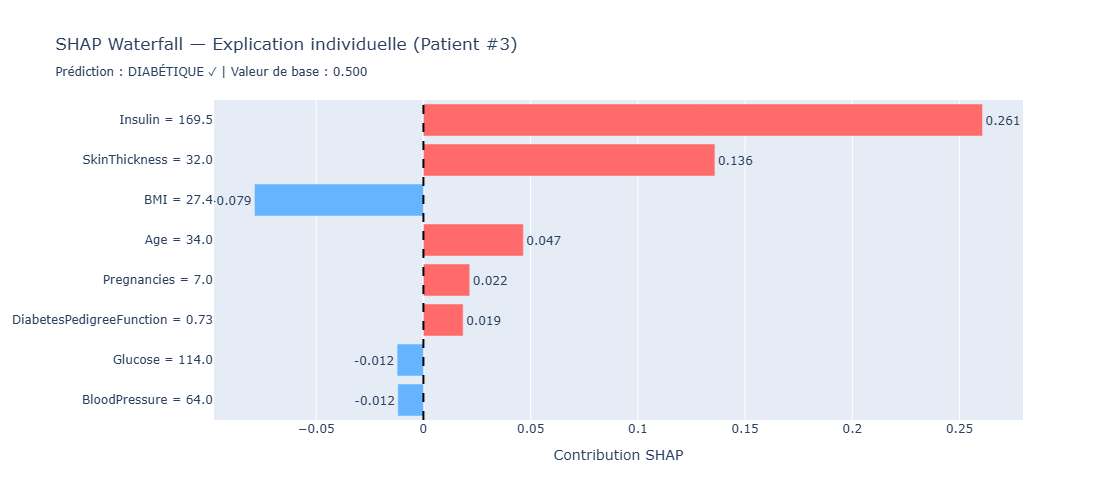


Détail du patient #3:
Pregnancies                   7.000
Glucose                     114.000
BloodPressure                64.000
SkinThickness                32.000
Insulin                     169.500
BMI                          27.400
DiabetesPedigreeFunction      0.732
Age                          34.000

Probabilité prédite : 88.0%


In [79]:

y_pred_final = rf_final.predict(X_test_scaled)
vrais_positifs = np.where((y_test.values == 1) & (y_pred_final == 1))[0]
idx_patient = vrais_positifs[0]  

shap_patient = shap_vals_class1[idx_patient]
feat_patient = X_test_scaled[idx_patient]
expected_value = explainer.expected_value[1]

feat_original = X_test.iloc[idx_patient]

contrib_df = pd.DataFrame({
    'Variable': feature_names,
    'Valeur_originale': feat_original.values.round(2),
    'SHAP': shap_patient
}).sort_values('SHAP', key=abs, ascending=True)

colors_bar = ['#ff6b6b' if v > 0 else '#66b3ff' for v in contrib_df['SHAP']]

fig = go.Figure(go.Bar(
    x=contrib_df['SHAP'],
    y=contrib_df.apply(lambda r: f"{r['Variable']} = {r['Valeur_originale']}", axis=1),
    orientation='h',
    marker_color=colors_bar,
    text=contrib_df['SHAP'].round(3),
    textposition='outside'
))

fig.add_vline(x=0, line_dash='dash', line_color='black')
fig.update_layout(
    title=f"SHAP Waterfall — Explication individuelle (Patient #{idx_patient})<br>"
          f"<sub>Prédiction : DIABÉTIQUE ✓ | Valeur de base : {expected_value:.3f}</sub>",
    xaxis_title="Contribution SHAP",
    height=500
)
fig.show()

print(f"\nDétail du patient #{idx_patient}:")
print(feat_original.to_string())
print(f"\nProbabilité prédite : {rf_final.predict_proba(X_test_scaled[[idx_patient]])[0][1]*100:.1f}%")

In [80]:


faux_negatifs  = np.where((y_test.values == 1) & (y_pred_final == 0))[0]
vrais_negatifs = np.where((y_test.values == 0) & (y_pred_final == 0))[0]

profils = {
    'Diabétique détecté ✓':    vrais_positifs[0],
    'Diabétique manqué ✗':     faux_negatifs[0] if len(faux_negatifs) > 0 else vrais_positifs[1],
    'Non-diabétique sain':      vrais_negatifs[0]
}

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=list(profils.keys()),
                    horizontal_spacing=0.08)

for col_idx, (label, idx) in enumerate(profils.items()):
    shap_p = shap_vals_class1[idx]
    feat_p = X_test.iloc[idx]
    
    contrib = pd.DataFrame({
        'Variable': feature_names,
        'SHAP': shap_p
    }).sort_values('SHAP', key=abs, ascending=True)
    
    colors_p = ['#ff6b6b' if v > 0 else '#66b3ff' for v in contrib['SHAP']]
    proba = rf_final.predict_proba(X_test_scaled[[idx]])[0][1]
    
    fig.add_trace(
        go.Bar(
            x=contrib['SHAP'],
            y=contrib['Variable'],
            orientation='h',
            marker_color=colors_p,
            name=label,
            showlegend=False,
            hovertemplate="SHAP: %{x:.3f}<extra></extra>"
        ),
        row=1, col=col_idx+1
    )
    
    fig.add_vline(x=0, line_dash='dash', line_color='black',
                  row=1, col=col_idx+1)

fig.update_layout(
    title="Comparaison SHAP — 3 profils patients",
    height=500
)
fig.show()


print("Probabilités prédites par profil :")
for label, idx in profils.items():
    proba = rf_final.predict_proba(X_test_scaled[[idx]])[0][1]
    print(f"  {label:30s} : {proba*100:.1f}% de risque diabétique")

Probabilités prédites par profil :
  Diabétique détecté ✓           : 88.0% de risque diabétique
  Diabétique manqué ✗            : 46.0% de risque diabétique
  Non-diabétique sain            : 15.0% de risque diabétique


In [81]:
import pickle
import os

os.makedirs("dashboard", exist_ok=True)

rf_final = [r for r in resultats_avec if 'Random Forest' in r['Modèle']][0]['model_obj']
with open("dashboard/model.pkl", "wb") as f:
    pickle.dump(rf_final, f)

with open("dashboard/scaler.pkl", "wb") as f:
    pickle.dump(sc, f)

print(" Modèle et scaler sauvegardés dans dashboard/")

 Modèle et scaler sauvegardés dans dashboard/
